# House Price Prediction – Machine Learning Project

## Business Problem
The goal of the project was to build a machine learning model that can predict house sale prices based on property features such as area, number of bedrooms, location, grade of the house, and other characteristics.

## Problem Framing

Target variable: house price per unit area

Since the target variable is continuous numerical data,
this is a **Supervised Machine Learning Regression problem**.

- Linear Regression
- Random Forest Regressor
- Gradient Boosting

In [22]:
# ===============================
# Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Dataset

In [23]:
df = pd.read_csv("../data/Raw_Housing_Prices.csv")
# View first records
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Dataset Overview

In [24]:
# Shape of dataset
df.shape

(21613, 21)

In [25]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [26]:
# Statistical summary
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Check Missing Values

In [27]:
df.isnull().sum()

ID                                               0
Date House was Sold                              0
Sale Price                                       4
No of Bedrooms                                   0
No of Bathrooms                                  4
Flat Area (in Sqft)                              9
Lot Area (in Sqft)                               9
No of Floors                                     0
Waterfront View                                  0
No of Times Visited                          19489
Condition of the House                           0
Overall Grade                                    0
Area of the House from Basement (in Sqft)        3
Basement Area (in Sqft)                          0
Age of House (in Years)                          0
Renovated Year                                   0
Zipcode                                          1
Latitude                                         1
Longitude                                        1
Living Area after Renovation (i

In [28]:
# Remove rows where the target variable (Sale Price) is missing
# because the model cannot learn without the correct target value
df = df.dropna(subset=["Sale Price"])

In [29]:
df.isnull().sum()

ID                                               0
Date House was Sold                              0
Sale Price                                       0
No of Bedrooms                                   0
No of Bathrooms                                  4
Flat Area (in Sqft)                              9
Lot Area (in Sqft)                               9
No of Floors                                     0
Waterfront View                                  0
No of Times Visited                          19485
Condition of the House                           0
Overall Grade                                    0
Area of the House from Basement (in Sqft)        3
Basement Area (in Sqft)                          0
Age of House (in Years)                          0
Renovated Year                                   0
Zipcode                                          1
Latitude                                         1
Longitude                                        1
Living Area after Renovation (i

In [30]:
# Drop column with excessive missing values
df = df.drop("No of Times Visited", axis=1)

# Fill missing numerical values using median

In [31]:

df["No of Bathrooms"] = df["No of Bathrooms"].fillna(df["No of Bathrooms"].median())

df["Flat Area (in Sqft)"] = df["Flat Area (in Sqft)"].fillna(df["Flat Area (in Sqft)"].median())

df["Lot Area (in Sqft)"] = df["Lot Area (in Sqft)"].fillna(df["Lot Area (in Sqft)"].median())

df["Area of the House from Basement (in Sqft)"] = df["Area of the House from Basement (in Sqft)"].fillna(
    df["Area of the House from Basement (in Sqft)"].median())

df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())

df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())

df["Living Area after Renovation (in Sqft)"] = df["Living Area after Renovation (in Sqft)"].fillna(
    df["Living Area after Renovation (in Sqft)"].median())
df["Zipcode"] = df["Zipcode"].fillna(df["Zipcode"].mode()[0])

In [32]:
df.isnull().sum()

ID                                           0
Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64

In [33]:
# Drop ID column because it is only an identifier
df = df.drop(columns=["ID"])

In [34]:
df.columns

Index(['Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'Condition of the House',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

## Exploratory Data Analysis (EDA)

In this step we analyze the dataset to understand the
distribution of variables, relationships between features,
and patterns that may influence the target variable
(Sale Price).

### 1. Distribution of Sale Price

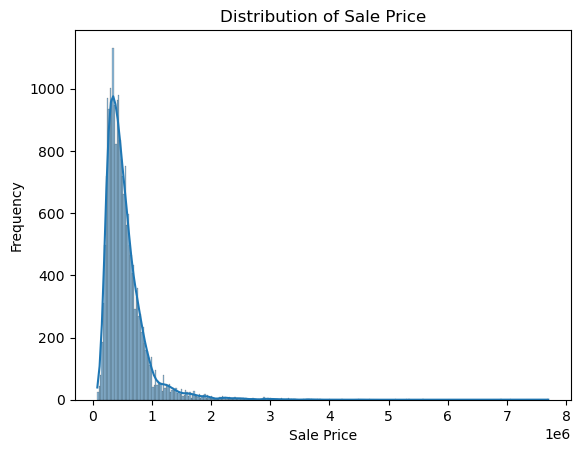

In [35]:
# Plot distribution of Sale Price
sns.histplot(df["Sale Price"], kde=True)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.savefig("../outputs/sale_price_distribution.png")
plt.show()

## Most houses are concentrated in the lower price range. A small number of houses have very high prices, creating a long tail on the right side.This indicates that the Sale Price distribution is right-skewed.

### 2 Checking the relationship between house size and price.

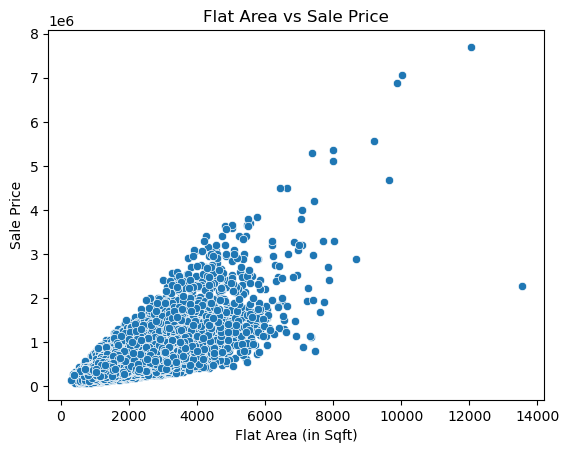

In [36]:
sns.scatterplot(
    x=df["Flat Area (in Sqft)"],
    y=df["Sale Price"])

plt.title("Flat Area vs Sale Price")
plt.savefig("../outputs/sale_price_distribution.png")
plt.show()

### 3. Correlation Analysis Between Features
A correlation heatmap helps identify the relationship between
different variables in the dataset. It shows how strongly each
feature is related to the target variable (Sale Price) and to
other features.

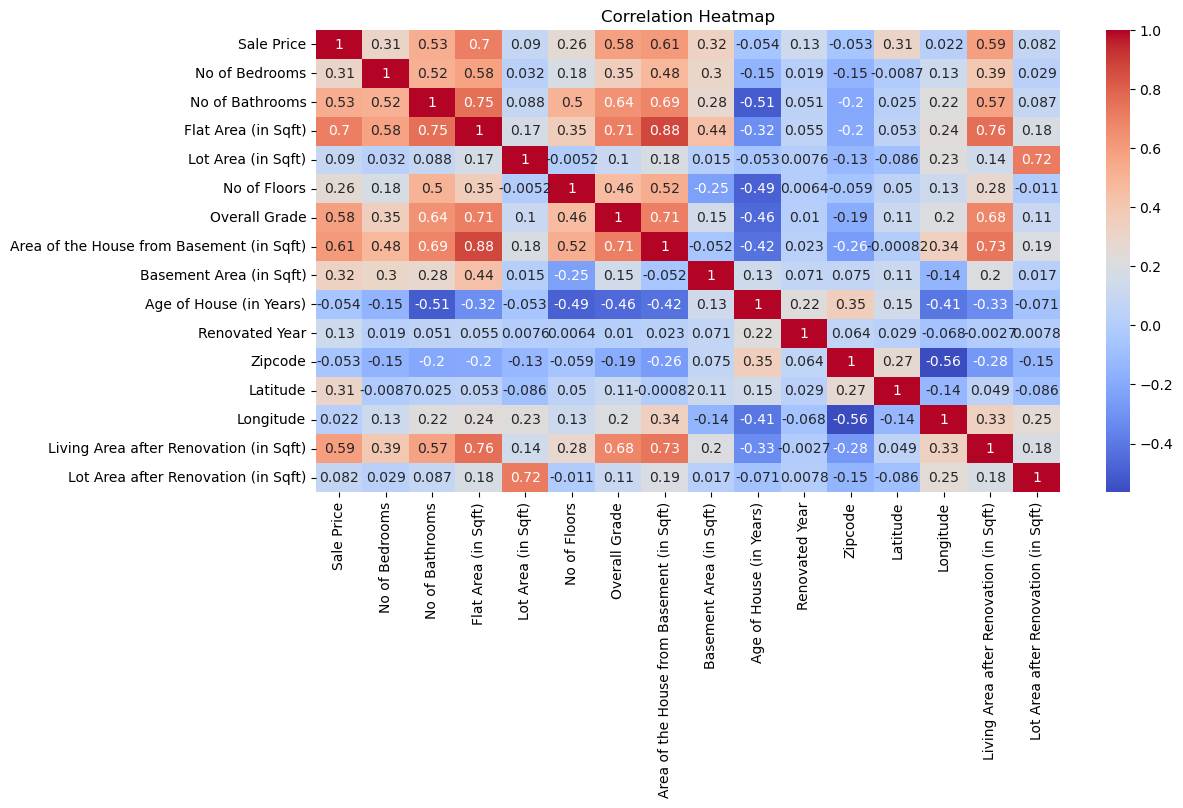

In [37]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("../outputs/flat_area_vs_sale_price.png")
plt.show()

The correlation heatmap shows that Flat Area,Area of the House from Basement, Living Area after Renovation,Overall Grade, and Number of Bathrooms have strong positive correlation with Sale Price.This indicates that larger houses and better quality housesgenerally have higher prices.Some variables such as Zipcode and Lot Area show weak correlation with Sale Price.

### 4. Outlier Detection in Sale Price

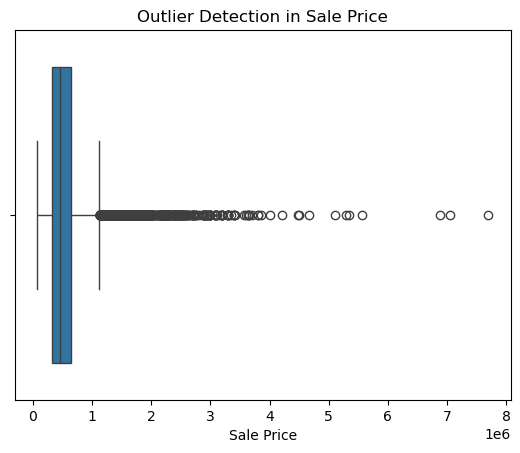

In [38]:
sns.boxplot(x=df["Sale Price"])
plt.title("Outlier Detection in Sale Price")
plt.savefig("../outputs/sale_price_outliers.png")
plt.show()

### 5. Outlier Detection in Flat Area

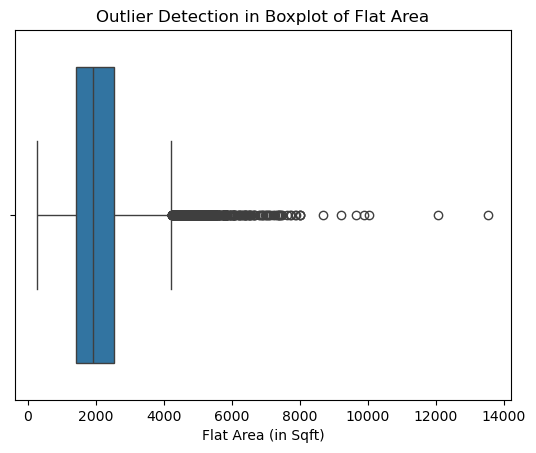

In [39]:
sns.boxplot(x=df["Flat Area (in Sqft)"])
plt.title("Outlier Detection in Boxplot of Flat Area")
plt.show()

### 6. Outlier Detection in Lot Area

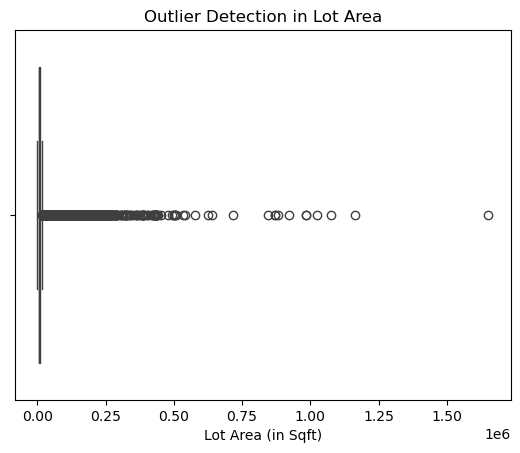

In [40]:
sns.boxplot(x=df["Lot Area (in Sqft)"])
plt.title("Outlier Detection in Lot Area")
plt.show()

The boxplot of Lot Area shows a large number of outliers. Most properties have relatively small lot sizes, while a few properties have extremely large land areas. This results in a highly right-skewed distribution.

### 7. Distribution of Flat Area

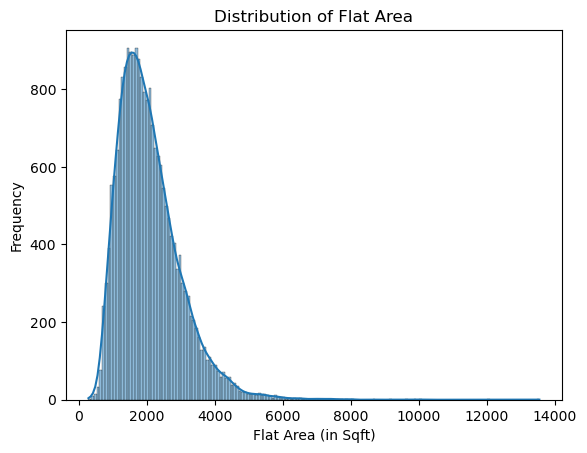

In [41]:
sns.histplot(df["Flat Area (in Sqft)"], kde=True)

plt.title("Distribution of Flat Area")
plt.xlabel("Flat Area (in Sqft)")
plt.ylabel("Frequency")
plt.show()

The distribution of Flat Area is right-skewed.
Most houses have a flat area between 1000 and 2500 sqft,
while a small number of houses have very large sizes,
creating a long tail on the right side.

## Feature Engineering

### 1. Converting Date Column to Datetime Format

In [42]:
df["Date House was Sold"] = pd.to_datetime(df["Date House was Sold"])

In [43]:
df["Date House was Sold"].dtype

dtype('<M8[ns]')

### 2. Extract Year and Month from Date

In [44]:
df["Sale Year"] = df["Date House was Sold"].dt.year
df["Sale Month"] = df["Date House was Sold"].dt.month

In [45]:
df[["Date House was Sold","Sale Year","Sale Month"]].head()

,Date House was Sold,Sale Year,Sale Month
0,2017-10-14,2017,10
1,2017-12-14,2017,12
2,2016-02-15,2016,2
3,2017-12-14,2017,12
4,2016-02-15,2016,2


In [46]:
df = df.drop("Date House was Sold", axis=1)

### 3. Identifying Categorical Features

In [47]:
df.select_dtypes(include="object").columns

Index(['Waterfront View', 'Condition of the House'], dtype='object')

### 4. Encoding Categorical Features

In [48]:
# One-Hot Encoding for a multiple categories.
df = pd.get_dummies(df, columns=["Condition of the House"], drop_first=True)

In [49]:
df.columns

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Waterfront View', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Sale Year', 'Sale Month',
       'Condition of the House_Excellent', 'Condition of the House_Fair',
       'Condition of the House_Good', 'Condition of the House_Okay'],
      dtype='object')

In [50]:
df["Waterfront View"].unique()

array(['No', 'Yes'], dtype=object)

### Encoding Waterfront View Column

In [51]:
# Binary Encoding for yes and no 
df["Waterfront View"] = df["Waterfront View"].map({"No":0, "Yes":1})

In [52]:
df["Waterfront View"].unique()

array([0, 1])

# Model Preparation

### Defining Features and Target Variable
#### X contains all input features. y contains the target variable.

In [53]:
X = df.drop("Sale Price", axis=1)
y = df["Sale Price"]

### Train-Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [55]:
X_train.shape

(17287, 22)

In [56]:
X_test.shape

(4322, 22)

In [57]:
y_train.shape

(17287,)

## Model Training

### Linear Regression Model

In this step we train a Linear Regression model to learn the relationship
between house features and the sale price. Linear Regression is used as
a baseline model for regression problems.

In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Model Prediction

In [59]:
y_pred = model.predict(X_test)

### Inspecting Model Predictions

In [60]:
y_pred[:10]

array([719199.4253098 , 626137.92512444,  27722.25145756, 345955.61086792,
       435426.30714779, 692222.00519268, 909581.41910238, 779380.25686798,
       442600.02883919, 910870.6523594 ])

### Comparing Actual vs Predicted Prices

In [61]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
comparison.reset_index(drop=True, inplace=True)
comparison.head(10)

,Actual Price,Predicted Price
0,570000.0,719199.425310
1,720001.0,626137.925124
2,267000.0,27722.251458
3,365000.0,345955.610868
4,397000.0,435426.307148
5,585000.0,692222.005193
6,1100000.0,909581.419102
7,755000.0,779380.256868
8,270000.0,442600.028839
9,555000.0,910870.652359


### Model Evaluation

In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.6828774925198828
MAE: 133804.07992658264
RMSE: 215051.19218570006


The Linear Regression model is evaluated using R² Score, MAE, and RMSE
to understand how well the model predicts house prices.
1. R² = 0.6828 (The model explains about 68% of the variation in house prices.)
2. MAE = 133804 (On average, the model prediction is off by about 133,804.)
3. RMSE = 215051 (Typical prediction error is around 215k) and (Typical prediction error is around 215k)

### Residual Analysis

### Residual analysis helps evaluate how well the model predictions match the actual values. Residuals represent the difference between the actual and predicted house prices.
[y_test → actual house prices] 
[y_pred → predicted house prices]

In [63]:
residuals = y_test - y_pred

In [64]:
residuals[:10]

4984    -149199.425310
10256     93863.074876
4046     239277.748542
21269     19044.389132
10496    -38426.307148
2201    -107222.005193
9215     190418.580898
9978     -24380.256868
2325    -172600.028839
6099    -355870.652359
Name: Sale Price, dtype: float64

### Residual Plot
A residual plot helps visualize the difference between the predicted
and actual values. It is used to check whether the model errors are
randomly distributed or if there is a pattern in the prediction errors.

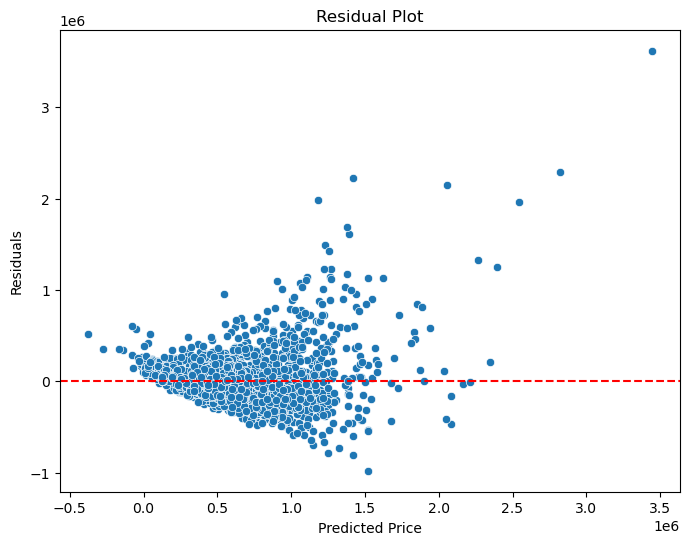

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Decision Tree Regression Model
Decision Tree Regression is a non-linear machine learning model that
splits the dataset into branches based on feature values. It can capture
complex relationships between house features and sale price.

In [66]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [67]:
y_pred_tree = tree_model.predict(X_test)

### Inspecting Decision Tree Predictions

In [68]:
y_pred_tree[:10]

array([487600., 490000., 247000., 379000., 650000., 650000., 915000.,
       731688., 325000., 475000.])

### Comparing Actual vs Predicted Prices (Decision Tree)
This step compares the actual house prices with the predicted prices
generated by the Decision Tree model to visually inspect prediction quality.

In [69]:
comparison_tree = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_tree})
comparison_tree.reset_index(drop=True, inplace=True)
comparison_tree.head(10)

,Actual Price,Predicted Price
0,570000.0,487600.0
1,720001.0,490000.0
2,267000.0,247000.0
3,365000.0,379000.0
4,397000.0,650000.0
5,585000.0,650000.0
6,1100000.0,915000.0
7,755000.0,731688.0
8,270000.0,325000.0
9,555000.0,475000.0


### Decision Tree Model Evaluation

In [70]:
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("Decision Tree R2:", r2_tree)
print("Decision Tree MAE:", mae_tree)
print("Decision Tree RMSE:", rmse_tree)

Decision Tree R2: 0.7463901199419438
Decision Tree MAE: 104909.08398889402
Decision Tree RMSE: 192314.22338348272


### Model Comparison
The performance of Linear Regression and Decision Tree models
is compared using evaluation metrics such as R² Score,
Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [71]:
comparison_models = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R2 Score": [r2, r2_tree],
    "MAE": [mae, mae_tree],
    "RMSE": [rmse, rmse_tree]
})

comparison_models

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.682877,133804.079927,215051.192186
1,Decision Tree,0.746390,104909.083989,192314.223383


## Random Forest Regression Model
Random Forest Regression is an ensemble learning method that
builds multiple decision trees and combines their predictions
to improve accuracy and reduce overfitting.

In [72]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [73]:
y_pred_rf = rf_model.predict(X_test)

### Inspecting Random Forest Predictions

In [74]:
y_pred_rf[:10]

array([ 526955.5 ,  612065.04,  233238.9 ,  351554.5 ,  555818.62,
        658948.5 , 1151376.48,  747634.2 ,  314272.64,  580751.75])

### Comparing Actual vs Predicted Prices (Random Forest)
This step compares the actual house prices with the predicted
prices generated by the Random Forest model to visually inspect
prediction quality.

In [75]:
comparison_rf = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_rf})

comparison_rf.reset_index(drop=True, inplace=True)

comparison_rf.head(10)

,Actual Price,Predicted Price
0,570000.0,526955.50
1,720001.0,612065.04
2,267000.0,233238.90
3,365000.0,351554.50
4,397000.0,555818.62
5,585000.0,658948.50
6,1100000.0,1151376.48
7,755000.0,747634.20
8,270000.0,314272.64
9,555000.0,580751.75


### Random Forest Model Evaluation

In [76]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2: 0.8744501972314256
Random Forest MAE: 71806.20720904674
Random Forest RMSE: 135312.00787408138


### Model Comparison

In [77]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [r2, r2_tree, r2_rf],
    "MAE": [mae, mae_tree, mae_rf],
    "RMSE": [rmse, rmse_tree, rmse_rf]})
comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.682877,133804.079927,215051.192186
1,Decision Tree,0.746390,104909.083989,192314.223383
2,Random Forest,0.874450,71806.207209,135312.007874


### Hyperparameter Tuning using GridSearchCV
Hyperparameter tuning is performed to optimize the Random Forest
model by searching for the best combination of parameters that
improve model performance.

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [79]:
best_rf = grid_search.best_estimator_

### Evaluation of Tuned Random Forest Model

In [80]:
y_pred_best = best_rf.predict(X_test)

In [81]:
print("Tuned Random Forest R2:", r2_score(y_test, y_pred_best))
print("Tuned Random Forest MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Tuned Random Forest R2: 0.8744035529771879
Tuned Random Forest MAE: 71382.19375329529
Tuned Random Forest RMSE: 135337.14109393442


### Final Model Comparison

In [82]:
final_models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"],
    "R2 Score": [r2, r2_tree, r2_rf, r2_score(y_test, y_pred_best)],
    "MAE": [mae, mae_tree, mae_rf, mean_absolute_error(y_test, y_pred_best)],
    "RMSE": [rmse, rmse_tree, rmse_rf, np.sqrt(mean_squared_error(y_test, y_pred_best))]
})

final_models

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.682877,133804.079927,215051.192186
1,Decision Tree,0.746390,104909.083989,192314.223383
2,Random Forest,0.874450,71806.207209,135312.007874
3,Tuned Random Forest,0.874404,71382.193753,135337.141094


### XGBoost Regression Model
XGBoost is an advanced gradient boosting algorithm that builds
decision trees sequentially. Each new tree learns from the errors
of previous trees, improving prediction accuracy.

In [83]:
# !pip install xgboost
from xgboost import XGBRegressor

In [84]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### XGBoost Predictions

In [85]:
y_pred_xgb = xgb_model.predict(X_test)

### Comparing Actual vs Predicted Prices (XGBoost)

In [86]:
comparison_xgb = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_xgb})

comparison_xgb.reset_index(drop=True, inplace=True)

comparison_xgb.head(10)

,Actual Price,Predicted Price
0,570000.0,5.153712e+05
1,720001.0,6.150850e+05
2,267000.0,2.725344e+05
3,365000.0,3.385889e+05
4,397000.0,5.025727e+05
5,585000.0,6.375942e+05
6,1100000.0,1.152765e+06
7,755000.0,7.242608e+05
8,270000.0,3.470148e+05
9,555000.0,5.619091e+05


### XGBoost Model Evaluation

In [87]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost R2:", r2_xgb)
print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost R2: 0.8867038424430929
XGBoost MAE: 65590.50284879685
XGBoost RMSE: 128539.29441303456


### Final Model Comparison

In [88]:
final_models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"],
    "R2 Score": [
        r2,
        r2_tree,
        r2_rf,
        r2_score(y_test, y_pred_best),
        r2_xgb],
    "MAE": [
        mae,
        mae_tree,
        mae_rf,
        mean_absolute_error(y_test, y_pred_best),
        mae_xgb],
    "RMSE": [
        rmse,
        rmse_tree,
        rmse_rf,
        np.sqrt(mean_squared_error(y_test, y_pred_best)),
        rmse_xgb]
})

final_models

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.682877,133804.079927,215051.192186
1,Decision Tree,0.746390,104909.083989,192314.223383
2,Random Forest,0.874450,71806.207209,135312.007874
3,Tuned Random Forest,0.874404,71382.193753,135337.141094
4,XGBoost,0.886704,65590.502849,128539.294413


### Feature Importance Analysis

In [89]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns)

feature_importance.sort_values(ascending=False)

Overall Grade                                0.343125
Waterfront View                              0.182100
Flat Area (in Sqft)                          0.160049
Latitude                                     0.068246
Longitude                                    0.035566
Living Area after Renovation (in Sqft)       0.031109
No of Bathrooms                              0.026777
Area of the House from Basement (in Sqft)    0.026154
Age of House (in Years)                      0.023635
Zipcode                                      0.019254
Condition of the House_Excellent             0.011095
Sale Year                                    0.010639
Lot Area after Renovation (in Sqft)          0.009927
Condition of the House_Fair                  0.009542
Lot Area (in Sqft)                           0.007982
Renovated Year                               0.006182
Basement Area (in Sqft)                      0.005913
Sale Month                                   0.005623
Condition of the House_Okay 

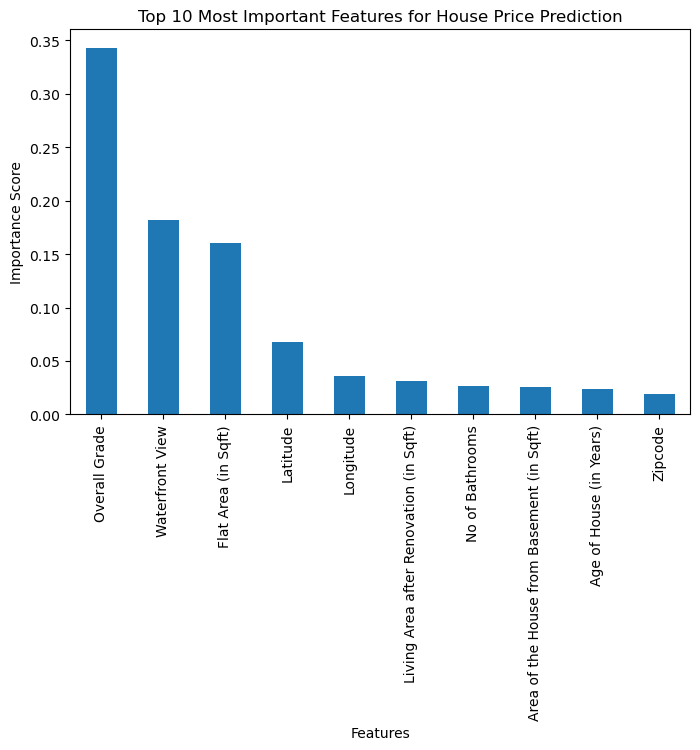

In [90]:
feature_importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 Most Important Features for House Price Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.savefig("../outputs/feature_importance.png")

plt.show()

### Saving the Final Model

In [91]:
import joblib

joblib.dump(xgb_model, "house_price_prediction_model.pkl")

['house_price_prediction_model.pkl']

### Project Conclusion

Multiple machine learning models were tested to predict house prices,
including Linear Regression, Decision Tree, Random Forest, and XGBoost.

After evaluating model performance using R² Score, MAE, and RMSE,
the XGBoost model achieved the best performance with an R² score
of approximately 0.886, indicating strong predictive capability.

Therefore, XGBoost was selected as the final model for house price prediction.